In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import xgboost

C:\Users\IRFAN SATHIK ALI\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('../churn-prediction-enhanced/data/churn_processed.csv')

# Find churn column
churn_col = None
for col in df.columns:
    if 'churn' in col.lower():
        churn_col = col
        break

print(f"✓ Loaded data shape: {df.shape}")
print(f"✓ Target column: {churn_col}")

✓ Loaded data shape: (10000, 49)
✓ Target column: churn


In [3]:
X = df.drop(columns=['customer_id',churn_col])
y = df[churn_col]

X['tenure_segment'] = X['tenure_segment'].map({
    '0-6 months': 0,
    '6-12 months': 1,
    '12-24 months': 2,
    '24+ months': 3
})
# Convert target to binary (0/1) if needed
if y.dtype == 'object':
    y = (y == y.unique()[1]).astype(int)

print(f"\n✓ Features: {X.shape[1]}")
print(f"✓ Churn rate: {y.mean()*100:.2f}%")


✓ Features: 47
✓ Churn rate: 10.21%


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Train set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")

✓ Train set: (8000, 47)
✓ Test set: (2000, 47)


In [5]:
print("\n" + "="*60)
print("Training XGBoost Model...")
print("="*60)

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train, y_train)


Training XGBoost Model...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [6]:
# Evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n✓ XGBoost Performance:")
print(f"  • Accuracy:  {accuracy:.4f}")
print(f"  • Precision: {precision:.4f}")
print(f"  • Recall:    {recall:.4f}")
print(f"  • F1-Score:  {f1:.4f}")
print(f"  • ROC-AUC:   {roc_auc:.4f}")


✓ XGBoost Performance:
  • Accuracy:  0.8950
  • Precision: 0.4118
  • Recall:    0.0686
  • F1-Score:  0.1176
  • ROC-AUC:   0.7901


In [8]:
print("\n" + "="*60)
print("Creating SHAP Explainer...")
print("="*60)

# Use TreeExplainer (optimized for XGBoost)
explainer = shap.TreeExplainer(model)
print("✓ Using TreeExplainer (optimized for XGBoost)")

# Calculate SHAP values
print("Calculating SHAP values (this takes ~30-60 seconds)...")
shap_values = explainer.shap_values(X_test)

# For binary classification, get churn class SHAP values
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # Churn class (class 1)
else:
    shap_vals = shap_values

print(f"✓ SHAP values calculated! Shape: {shap_vals.shape}")


Creating SHAP Explainer...
✓ Using TreeExplainer (optimized for XGBoost)
Calculating SHAP values (this takes ~30-60 seconds)...
✓ SHAP values calculated! Shape: (2000, 47)


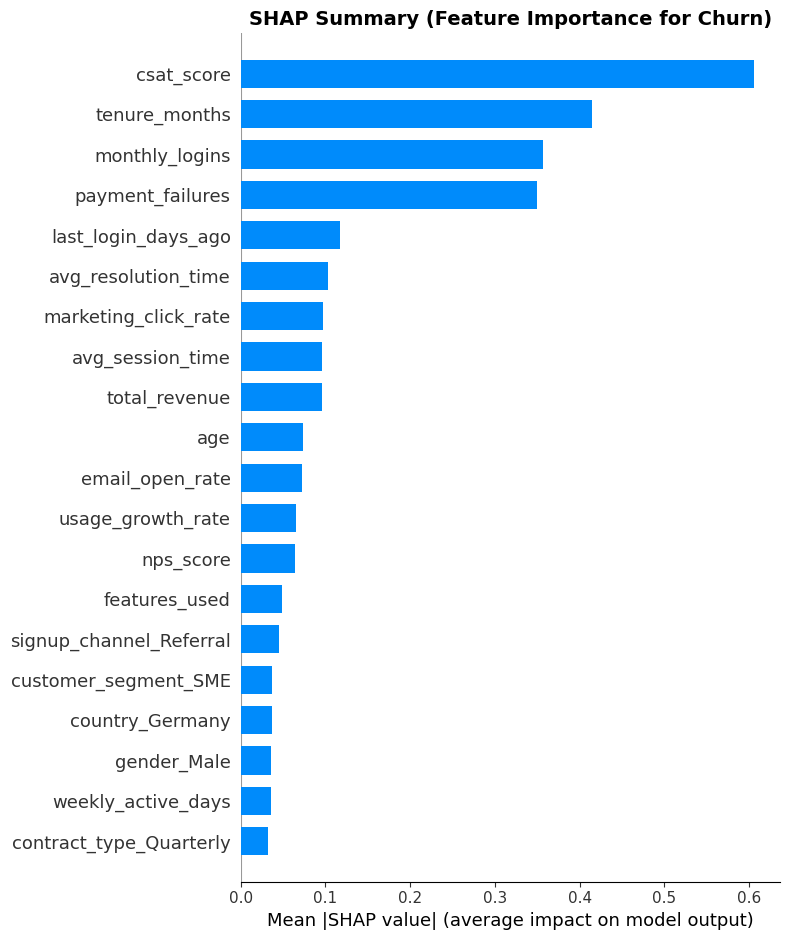


💡 Interpretation:
   - Taller bars = features that have more impact on churn
   - These are your KEY CHURN DRIVERS!


In [9]:
# For binary classification, take SHAP values for positive class (churn)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]  # Churn class
else:
    shap_vals = shap_values

# Summary plot (bar chart)
plt.figure()
shap.summary_plot(shap_vals, X, plot_type='bar', show=False)
plt.title('SHAP Summary (Feature Importance for Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP value| (average impact on model output)')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   - Taller bars = features that have more impact on churn")
print("   - These are your KEY CHURN DRIVERS!")

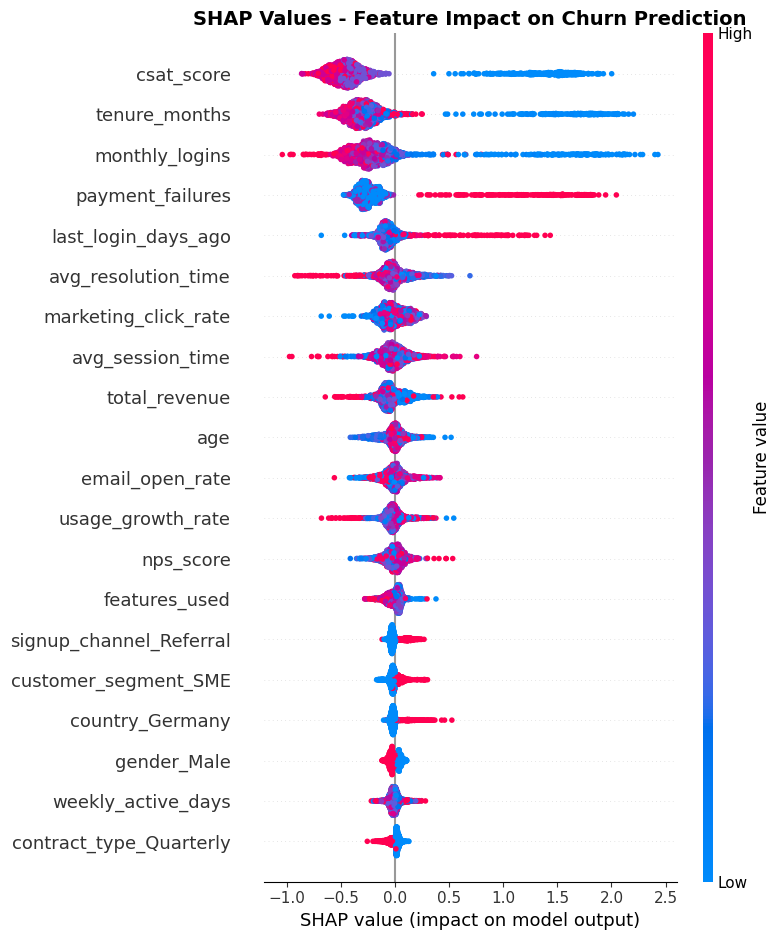


💡 Interpretation:
   - Red dots = high feature values
   - Blue dots = low feature values
   - Left/right position = whether feature pushes toward/away from churn


In [10]:
# Summary plot (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_test, show=False)
plt.title('SHAP Values - Feature Impact on Churn Prediction', fontsize=14, fontweight='bold')
plt.xlabel('SHAP value (impact on model output)')
plt.tight_layout()
plt.show()

print("\n💡 Interpretation:")
print("   - Red dots = high feature values")
print("   - Blue dots = low feature values")
print("   - Left/right position = whether feature pushes toward/away from churn")

In [16]:

# =====================================================
# Find Top 3 High-Risk Customers (using X_test)
# =====================================================

# Predict churn probabilities for X_test
y_pred_proba = model.predict_proba(X_test)

# Probability of churn (class 1)
churn_probs = y_pred_proba[:, 1]

# Get top 3 customers with highest churn probability
high_risk_indices = np.argsort(churn_probs)[-3:][::-1]

print("\nTop 3 High-Risk Customers")
print("=" * 60)

for rank, customer_idx in enumerate(high_risk_indices, start=1):

    print(f"\nCustomer #{rank}")
    print(f"Row Index in X_test : {customer_idx}")
    print(f"Churn Probability   : {churn_probs[customer_idx]*100:.2f}%")

    print("\nTop 5 Features Influencing Churn:")

    # SHAP values for this customer
    customer_shap = shap_values[customer_idx]

    # Top 5 important features
    top_features = np.argsort(np.abs(customer_shap))[-5:][::-1]

    for i, feat_idx in enumerate(top_features, start=1):

        feature_name = X_test.columns[feat_idx]
        feature_value = X_test.iloc[customer_idx, feat_idx]
        shap_value = customer_shap[feat_idx]

        if shap_value > 0:
            direction = "↑ Increases Churn Risk"
        else:
            direction = "↓ Decreases Churn Risk"

        print(f"{i}. {feature_name}")
        print(f"   Value      : {feature_value}")
        print(f"   SHAP Value : {shap_value:.4f}")
        print(f"   Effect     : {direction}")


Top 3 High-Risk Customers

Customer #1
Row Index in X_test : 1648
Churn Probability   : 83.08%

Top 5 Features Influencing Churn:
1. csat_score
   Value      : 2.0
   SHAP Value : 1.5515
   Effect     : ↑ Increases Churn Risk
2. tenure_months
   Value      : 1
   SHAP Value : 1.4293
   Effect     : ↑ Increases Churn Risk
3. avg_session_time
   Value      : 24.894736665855607
   SHAP Value : 0.3933
   Effect     : ↑ Increases Churn Risk
4. avg_resolution_time
   Value      : 14.36059687038656
   SHAP Value : 0.2683
   Effect     : ↑ Increases Churn Risk
5. marketing_click_rate
   Value      : 0.4
   SHAP Value : 0.1656
   Effect     : ↑ Increases Churn Risk

Customer #2
Row Index in X_test : 195
Churn Probability   : 77.94%

Top 5 Features Influencing Churn:
1. tenure_months
   Value      : 1
   SHAP Value : 1.7931
   Effect     : ↑ Increases Churn Risk
2. last_login_days_ago
   Value      : 34
   SHAP Value : 0.9606
   Effect     : ↑ Increases Churn Risk
3. email_open_rate
   Value   

<Figure size 1400x400 with 0 Axes>

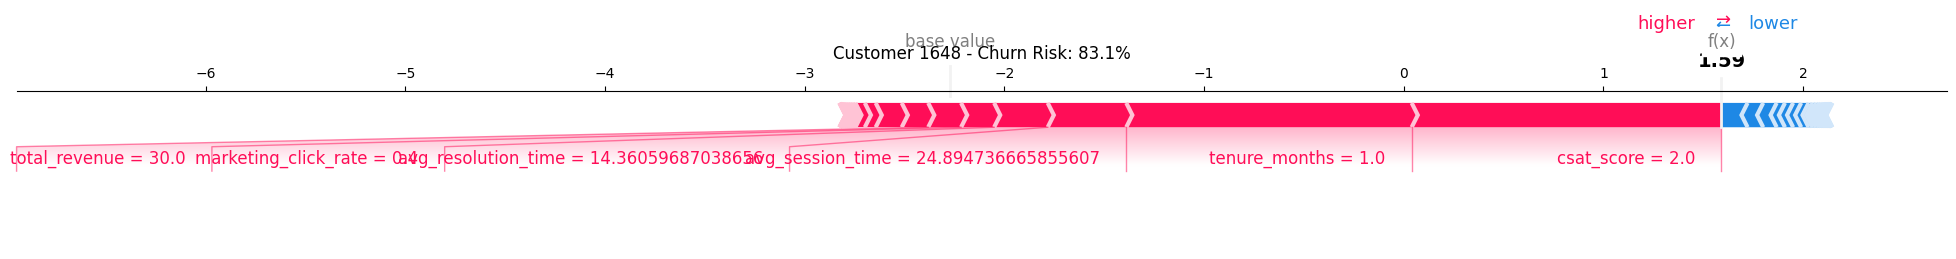


💡 Red features push toward churn, blue features reduce churn.


In [18]:

# First high-risk customer from X_test
customer_idx = high_risk_indices[0]

plt.figure(figsize=(14, 4))

shap.force_plot(
    explainer.expected_value,
    shap_vals[customer_idx],
    X_test.iloc[customer_idx],
    matplotlib=True,
    show=False
)

plt.title(f"Customer {customer_idx} - Churn Risk: {churn_probs[customer_idx]*100:.1f}%")
plt.tight_layout()
plt.show()

print("\n💡 Red features push toward churn, blue features reduce churn.")

In [21]:
print("\nCREATING CUSTOMER SEGMENTS BY CHURN REASON")
print("=" * 60)

# =====================================================
# Top 3 Important Features from SHAP
# =====================================================

feature_importance = np.mean(np.abs(shap_vals), axis=0)

top_features_idx = np.argsort(feature_importance)[-3:][::-1]
top_features = [X_test.columns[i] for i in top_features_idx]

print("\nTop 3 Churn Drivers:")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

# =====================================================
# Segment customers using the most important feature
# =====================================================

top_feature = top_features[0]

high_threshold = X_test[top_feature].quantile(0.75)
low_threshold = X_test[top_feature].quantile(0.25)

# =====================================================
# Create analysis dataframe
# =====================================================

df_analysis = X_test.copy()

df_analysis["actual_churn"] = y_test.values
df_analysis["predicted_churn_prob"] = churn_probs

# =====================================================
# High-risk segment
# =====================================================

high_segment = df_analysis[df_analysis[top_feature] >= high_threshold]

print("\nHIGH-RISK SEGMENT")
print("-" * 50)
print(f"Feature : {top_feature}")
print(f"Condition : >= {high_threshold:.2f}")
print(f"Customers : {len(high_segment)}")
print(f"Actual Churn Rate : {high_segment['actual_churn'].mean()*100:.2f}%")
print(f"Average Predicted Risk : {high_segment['predicted_churn_prob'].mean()*100:.2f}%")
print("Recommendation : High Priority for Retention")

# =====================================================
# Low-risk segment
# =====================================================

low_segment = df_analysis[df_analysis[top_feature] <= low_threshold]

print("\nLOW-RISK SEGMENT")
print("-" * 50)
print(f"Feature : {top_feature}")
print(f"Condition : <= {low_threshold:.2f}")
print(f"Customers : {len(low_segment)}")
print(f"Actual Churn Rate : {low_segment['actual_churn'].mean()*100:.2f}%")
print(f"Average Predicted Risk : {low_segment['predicted_churn_prob'].mean()*100:.2f}%")
print("Recommendation : Lower Priority")


CREATING CUSTOMER SEGMENTS BY CHURN REASON

Top 3 Churn Drivers:
1. csat_score
2. tenure_months
3. monthly_logins

HIGH-RISK SEGMENT
--------------------------------------------------
Feature : csat_score
Condition : >= 4.00
Customers : 1021
Actual Churn Rate : 7.54%
Average Predicted Risk : 6.91%
Recommendation : High Priority for Retention

LOW-RISK SEGMENT
--------------------------------------------------
Feature : csat_score
Condition : <= 3.00
Customers : 979
Actual Churn Rate : 12.97%
Average Predicted Risk : 12.34%
Recommendation : Lower Priority


In [22]:
# Business metrics
avg_customer_ltv = 5000  # $5000 average lifetime value (adjust based on your business)
retention_cost = 500     # $500 cost to retain a customer
success_rate = 0.70      # 70% success rate if we intervene

print("\nCOST-BENEFIT ANALYSIS")
print("="*60)
print(f"\nAssumptions:")
print(f"  - Customer Lifetime Value: ${avg_customer_ltv}")
print(f"  - Retention Intervention Cost: ${retention_cost}")
print(f"  - Success Rate if Intervened: {success_rate*100:.0f}%")

# Calculate ROI for each segment
for segment_name, segment_data in [('High Risk', high_segment), ('Low Risk', low_segment)]:
    segment_size = len(segment_data)
    churn_rate = segment_data['actual_churn'].mean()
    
    # Expected churners without intervention
    expected_churners = segment_size * churn_rate
    
    # Cost of intervention
    intervention_cost = segment_size * retention_cost
    
    # Value saved (customers we save × LTV)
    customers_saved = expected_churners * success_rate
    value_saved = customers_saved * avg_customer_ltv
    
    # ROI
    net_benefit = value_saved - intervention_cost
    roi = (net_benefit / intervention_cost) * 100 if intervention_cost > 0 else 0
    
    print(f"\n{segment_name} Segment:")
    print(f"  Segment size: {segment_size}")
    print(f"  Expected churners: {expected_churners:.0f}")
    print(f"  Intervention cost: ${intervention_cost:,.0f}")
    print(f"  Value saved (if successful): ${value_saved:,.0f}")
    print(f"  Net benefit: ${net_benefit:,.0f}")
    print(f"  ROI: {roi:.1f}%" if net_benefit > 0 else f"  ROI: NEGATIVE ({roi:.1f}%)")
    
    if roi > 100:
        print(f"  ✅ HIGHLY RECOMMENDED - Strong business case!")
    elif roi > 0:
        print(f"  ✓ Recommended - Positive ROI")
    else:
        print(f"  ✗ Not recommended - Negative ROI")


COST-BENEFIT ANALYSIS

Assumptions:
  - Customer Lifetime Value: $5000
  - Retention Intervention Cost: $500
  - Success Rate if Intervened: 70%

High Risk Segment:
  Segment size: 1021
  Expected churners: 77
  Intervention cost: $510,500
  Value saved (if successful): $269,500
  Net benefit: $-241,000
  ROI: NEGATIVE (-47.2%)
  ✗ Not recommended - Negative ROI

Low Risk Segment:
  Segment size: 979
  Expected churners: 127
  Intervention cost: $489,500
  Value saved (if successful): $444,500
  Net benefit: $-45,000
  ROI: NEGATIVE (-9.2%)
  ✗ Not recommended - Negative ROI
